# Facial Expression Report — Data Visualization

This notebook reads the `.xlsx` reports produced by `live_webcam.py` and
`detect_image_video.py` and turns them into charts.

**Folder structure this notebook expects** (created automatically by the two scripts):

```
report/
├── session_20260624_120000/      ← one folder per LIVE WEBCAM run
│   ├── summary.xlsx               (totals + built-in pie/bar charts)
│   └── timeline.xlsx              (per-sample log, for time-series charts)
├── my_video/                      ← one folder per processed VIDEO file
│   ├── summary.xlsx
│   └── timeline.xlsx
└── my_photo/                      ← one folder per processed IMAGE file
    └── detections.xlsx            (one row per detected face)
```

**How to use this notebook:**
1. Run every cell from top to bottom once (`Run All`).
2. Cell 3 lists every report folder it found — copy the folder name you want
   into `REPORT_FOLDER` in Cell 4 and re-run from there.
3. Each chart cell is independent — feel free to skip ones that don't apply
   (e.g. skip the time-series cells for an image report).

**One thing worth knowing:** the two scripts label the same emotions
slightly differently in Indonesian (`SERIUS`/`NGANTUK`/`NGOBROL` from the
live webcam script vs `NETRAL`/`SEDIH`/`TERKEJUT` from the image/video
script, for *neutral/sad/surprise*). This notebook's color map covers both
sets, so charts work correctly either way — just don't be surprised if a
live session and a video report use different words for what is the same
underlying expression.


## 1. Setup
Install (if needed) and import the libraries used below.

In [1]:
# Run once. Safe to re-run; pip will skip anything already installed.
# (If you're on a system that blocks pip installs outside a virtual
# environment, run this in a terminal first instead:
#   pip install pandas matplotlib seaborn openpyxl
# or activate your venv before launching Jupyter.)
%pip install -q pandas matplotlib seaborn openpyxl

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Libraries loaded.")



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


## 2. Shared settings

A single color per expression, used consistently across every chart in
this notebook so the same expression always looks the same color.
Covers both Indonesian label sets used by the two scripts.


In [2]:
# One fixed color per expression -- reused in every chart below.
# Covers labels from BOTH scripts (they word neutral/sad/surprise differently).
EXPRESSION_COLORS = {
    # live_webcam.py
    "MARAH": "#E53935",     # angry  -> red
    "JIJIK": "#FB8C00",     # disgust -> orange
    "TAKUT": "#8E24AA",     # fear   -> purple
    "SENANG": "#43A047",    # happy  -> green
    "SERIUS": "#9E9E9E",    # neutral -> grey
    "NGANTUK": "#1E88E5",   # sad    -> blue
    "NGOBROL": "#FDD835",   # surprise -> yellow
    # detect_image_video.py (different wording, same colors for the same emotion)
    "NETRAL": "#9E9E9E",    # neutral -> grey
    "SEDIH": "#1E88E5",     # sad    -> blue
    "TERKEJUT": "#FDD835",  # surprise -> yellow
}

def color_for(label):
    """Returns a color for a label; falls back to grey for anything unmapped."""
    return EXPRESSION_COLORS.get(label, "#BDBDBD")

print(f"{len(EXPRESSION_COLORS)} expression labels mapped to colors.")


10 expression labels mapped to colors.


## 3. Find available reports

Scans the `report/` folder and lists everything it finds, split into:
- **Live webcam sessions** (`session_*` folders, each with `summary.xlsx` + `timeline.xlsx`)
- **Video / image reports** (folders named after the source file)


In [3]:
REPORT_ROOT = "report"   # change this if your reports live somewhere else

session_folders = sorted(glob.glob(os.path.join(REPORT_ROOT, "session_*")))
other_folders = sorted([
    f for f in glob.glob(os.path.join(REPORT_ROOT, "*"))
    if os.path.isdir(f) and not os.path.basename(f).startswith("session_")
])

print("LIVE WEBCAM SESSIONS:")
if session_folders:
    for f in session_folders:
        print(f"  {f}")
else:
    print("  (none found)")

print("\nVIDEO / IMAGE REPORTS:")
if other_folders:
    for f in other_folders:
        is_video = os.path.exists(os.path.join(f, "summary.xlsx")) and os.path.exists(os.path.join(f, "timeline.xlsx"))
        kind = "video" if is_video else "image"
        print(f"  {f}   ({kind})")
else:
    print("  (none found)")


LIVE WEBCAM SESSIONS:
  report\session_20260624_143729
  report\session_20260624_144107

VIDEO / IMAGE REPORTS:
  (none found)


## 4. Choose a report to analyze

Paste one of the folder paths printed above into `REPORT_FOLDER`.

- For a **live webcam session** or a **video**, leave `HAS_TIMELINE = True`
  (these have both `summary.xlsx` and `timeline.xlsx`).
- For a **single image**, set `HAS_TIMELINE = False` and skip ahead to
  **Section 8** (the image-specific chart) -- the time-series sections
  in between don't apply to a single still image.


In [4]:
REPORT_FOLDER = "report/session_20260624_144107"   # <-- change this to the folder you want
HAS_TIMELINE = True                                  # False if this is a single-image report

print(f"Analyzing: {REPORT_FOLDER}")
print(f"Contents: {os.listdir(REPORT_FOLDER)}")


Analyzing: report/session_20260624_144107
Contents: ['summary.xlsx', 'timeline.xlsx']


## 5. Load the data

`summary.xlsx` totals are loaded from the **Summary** sheet (the real data
starts a few rows down, after the report header). The percentage column is
recomputed directly in pandas rather than trusted from the Excel file,
since Excel formulas are stored as text by the report script and only show
their calculated value after the file has actually been opened in Excel at least once.


In [5]:
summary_path = os.path.join(REPORT_FOLDER, "summary.xlsx")

summary_df = pd.read_excel(summary_path, sheet_name="Summary", header=5)
summary_df = summary_df.dropna(subset=["Expression"]).reset_index(drop=True)
summary_df["Seconds"] = summary_df["Seconds"].astype(float)
summary_df["Percent"] = (summary_df["Seconds"] / summary_df["Seconds"].sum() * 100).round(1)

print(f"{len(summary_df)} expression(s) detected in this report.")
summary_df


3 expression(s) detected in this report.


,Expression,Seconds,% of total face-time,Percent
0,SERIUS,347.5,NaN,69.3
1,NGANTUK,130.1,NaN,25.9
2,NGOBROL,23.8,NaN,4.7


In [6]:
if HAS_TIMELINE:
    timeline_path = os.path.join(REPORT_FOLDER, "timeline.xlsx")
    timeline_df = pd.read_excel(timeline_path)

    # The face-count column is named slightly differently depending on which
    # script produced the report -- detect it automatically.
    face_col_candidates = ["Faces detected (this sample)", "Faces detected (this frame)"]
    FACE_COL = next(c for c in face_col_candidates if c in timeline_df.columns)

    # Every column except "Elapsed (s)" and the face-count column is an expression.
    EXPR_COLS = [c for c in timeline_df.columns if c not in ("Elapsed (s)", FACE_COL)]

    print(f"{len(timeline_df)} time samples loaded.")
    print(f"Expression columns: {EXPR_COLS}")
    timeline_df.head()
else:
    print("HAS_TIMELINE is False -- skip to Section 8 for the image-only chart.")


3094 time samples loaded.
Expression columns: ['SERIUS', 'NGANTUK', 'NGOBROL']


## 6. Overview charts — total time per expression

Two views of the same numbers: a **bar chart** (easy to read exact values)
and a **pie chart** (easy to see relative share at a glance).


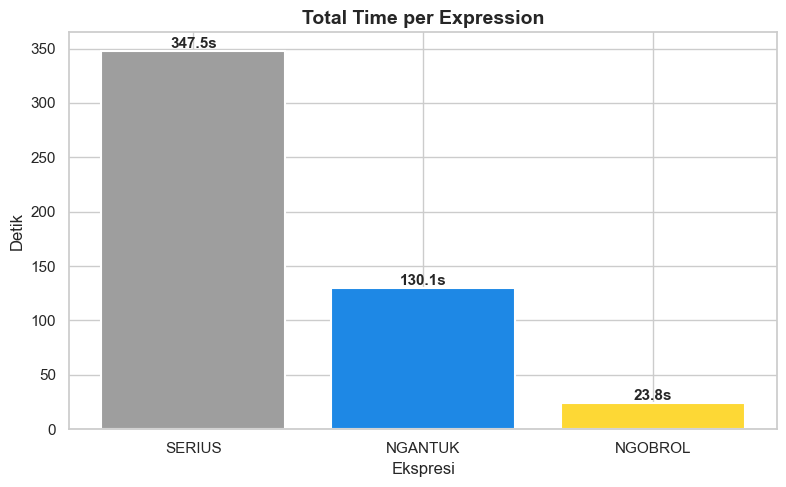

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [color_for(e) for e in summary_df["Expression"]]
bars = ax.bar(summary_df["Expression"], summary_df["Seconds"], color=colors, edgecolor="white", linewidth=1.5)

for bar, seconds in zip(bars, summary_df["Seconds"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{seconds:.1f}s", ha="center", va="bottom", fontweight="bold")

ax.set_title("Total Time per Expression", fontsize=14, fontweight="bold")
ax.set_ylabel("Detik")
ax.set_xlabel("Ekspresi")
plt.tight_layout()
plt.show()


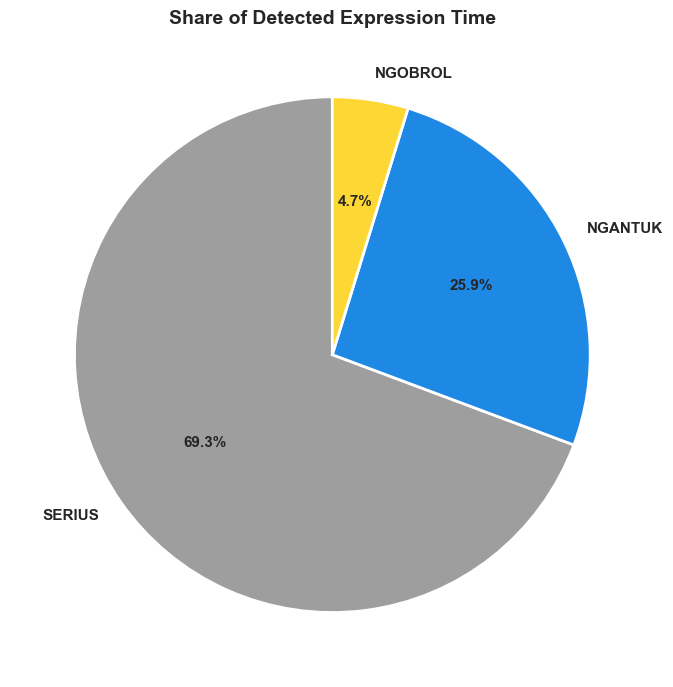

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = [color_for(e) for e in summary_df["Expression"]]

ax.pie(
    summary_df["Seconds"],
    labels=summary_df["Expression"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontweight": "bold"},
)
ax.set_title("Share of Detected Expression Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Time-series charts

These only make sense when there's a timeline (live webcam session or
video) — **skip this whole section for a single-image report.**


### 7a. Expression activity over time (stacked area)

Each colored band shows how much of that expression was detected at each
moment. Wider band = more face-time with that expression at that point.


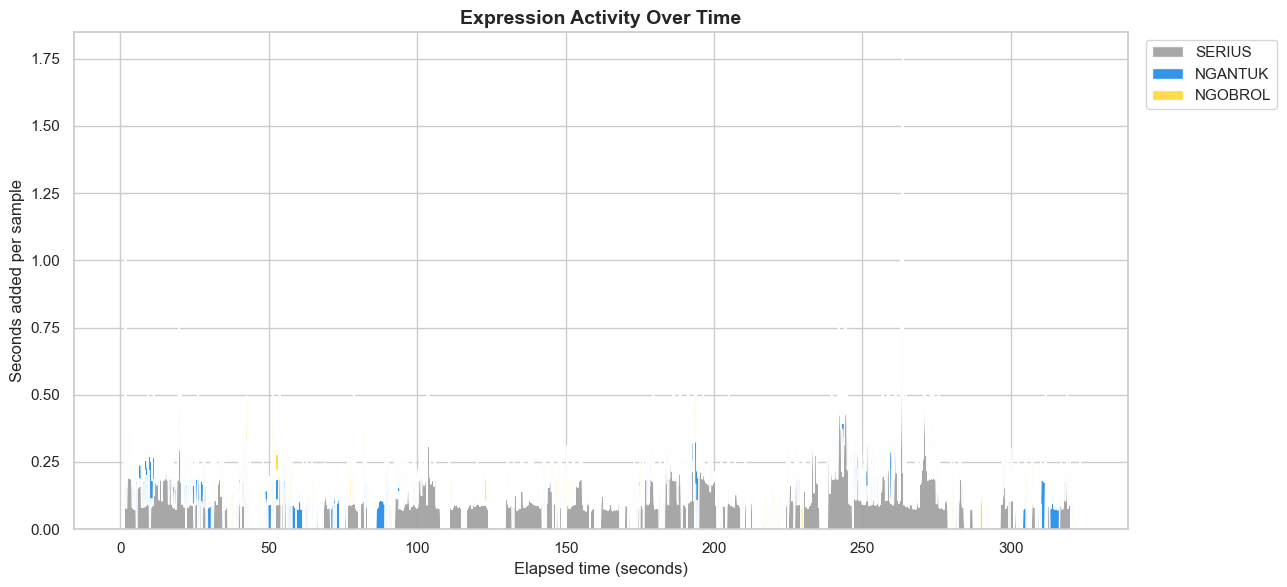

In [9]:
if HAS_TIMELINE:
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.stackplot(
        timeline_df["Elapsed (s)"],
        *[timeline_df[c] for c in EXPR_COLS],
        labels=EXPR_COLS,
        colors=[color_for(c) for c in EXPR_COLS],
        alpha=0.9,
    )
    ax.set_title("Expression Activity Over Time", fontsize=14, fontweight="bold")
    ax.set_xlabel("Elapsed time (seconds)")
    ax.set_ylabel("Seconds added per sample")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()


### 7b. How many faces were on screen over time

Useful context for the chart above — a spike in some expression might just
mean more people appeared, not that everyone suddenly felt that way.


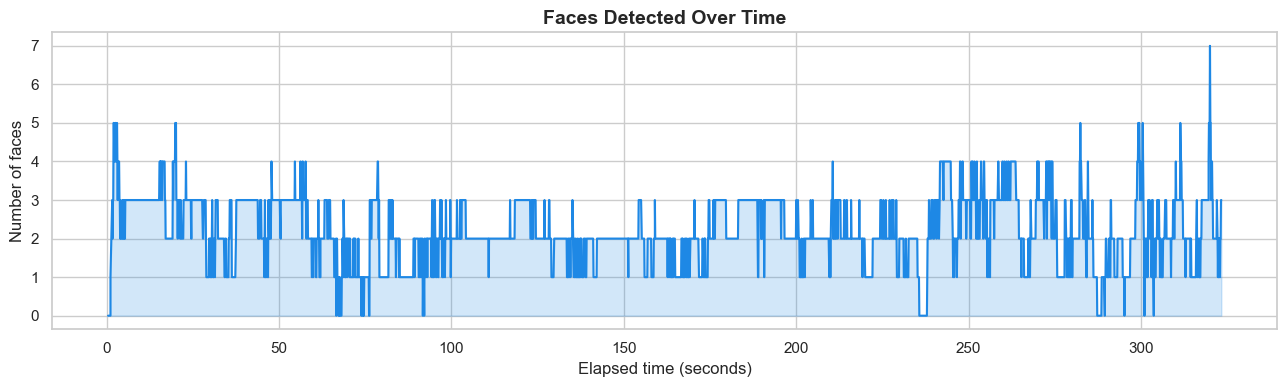

In [10]:
if HAS_TIMELINE:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(timeline_df["Elapsed (s)"], timeline_df[FACE_COL], color="#1E88E5", linewidth=1.5)
    ax.fill_between(timeline_df["Elapsed (s)"], timeline_df[FACE_COL], alpha=0.2, color="#1E88E5")
    ax.set_title("Faces Detected Over Time", fontsize=14, fontweight="bold")
    ax.set_xlabel("Elapsed time (seconds)")
    ax.set_ylabel("Number of faces")
    plt.tight_layout()
    plt.show()


### 7c. Dominant expression per time window

Splits the session into fixed windows (default 10 seconds) and shows which
expression had the most accumulated time in each window — a quick "mood
timeline" at a glance.


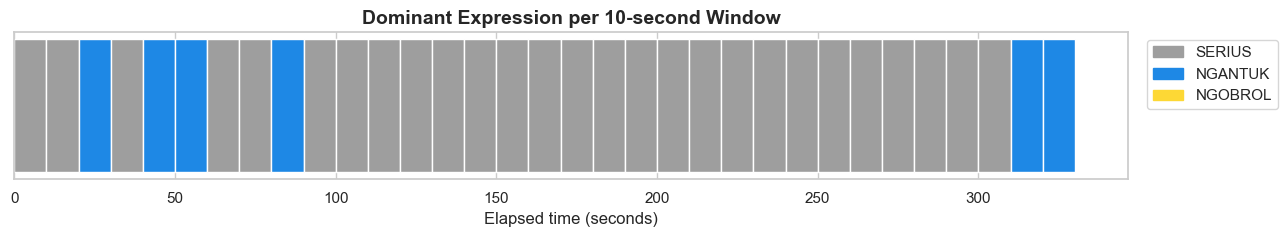

In [11]:
if HAS_TIMELINE:
    WINDOW_SECONDS = 10   # change this to make windows shorter/longer

    timeline_df["window"] = (timeline_df["Elapsed (s)"] // WINDOW_SECONDS).astype(int)
    windowed = timeline_df.groupby("window")[EXPR_COLS].sum()
    dominant = windowed.idxmax(axis=1)

    fig, ax = plt.subplots(figsize=(13, 2.5))
    for window_idx, label in dominant.items():
        ax.barh(0, WINDOW_SECONDS, left=window_idx * WINDOW_SECONDS,
                color=color_for(label), edgecolor="white")

    ax.set_yticks([])
    ax.set_xlabel("Elapsed time (seconds)")
    ax.set_title(f"Dominant Expression per {WINDOW_SECONDS}-second Window", fontsize=14, fontweight="bold")

    handles = [plt.Rectangle((0, 0), 1, 1, color=color_for(l)) for l in EXPR_COLS]
    ax.legend(handles, EXPR_COLS, loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()


### 7d. Intensity heatmap

A different angle on the same windowed data — darker/redder cells mean more
seconds of that expression in that time window. Good for spotting brief
spikes that a stacked area chart can visually hide.


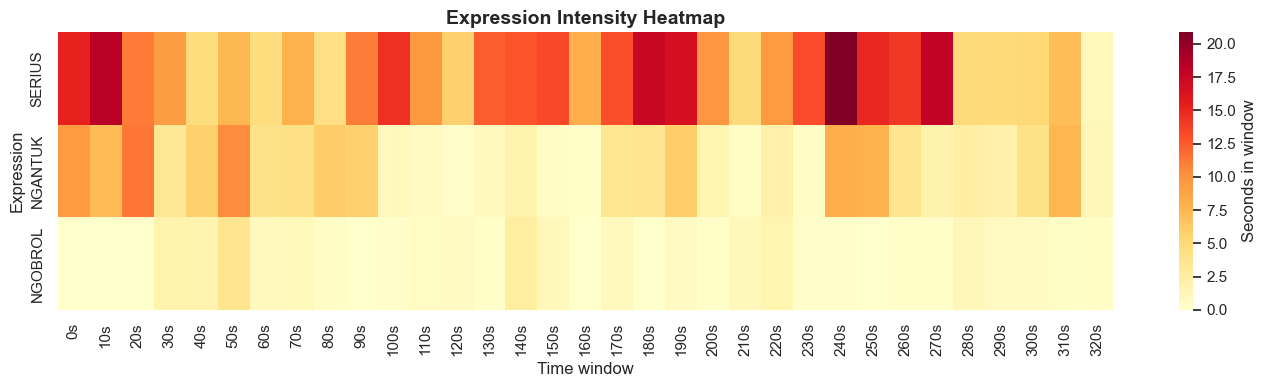

In [12]:
if HAS_TIMELINE:
    heat_data = windowed.T.copy()
    heat_data.columns = [f"{int(w * WINDOW_SECONDS)}s" for w in heat_data.columns]

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(heat_data, cmap="YlOrRd", cbar_kws={"label": "Seconds in window"}, ax=ax)
    ax.set_title("Expression Intensity Heatmap", fontsize=14, fontweight="bold")
    ax.set_xlabel("Time window")
    ax.set_ylabel("Expression")
    plt.tight_layout()
    plt.show()


## 8. Image report (single photo only)

If you're analyzing a `detections.xlsx` from a processed **image** instead
of a video/webcam session, run this section instead of Sections 6-7. Shows
each detected face's expression and how confident the model was.


In [ ]:
# Only relevant for an image report. Change the path if needed.
IMAGE_REPORT_PATH = "report/my_photo/detections.xlsx"

if os.path.exists(IMAGE_REPORT_PATH):
    img_df = pd.read_excel(IMAGE_REPORT_PATH, sheet_name="Detections", header=5)
    img_df = img_df.dropna(subset=["Face #"]).reset_index(drop=True)
    print(f"{len(img_df)} face(s) detected in this image.")
    img_df
else:
    print(f"No file found at {IMAGE_REPORT_PATH} -- update the path above.")


In [ ]:
if os.path.exists(IMAGE_REPORT_PATH) and len(img_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = [color_for(e) for e in img_df["Expression"]]
    bars = ax.bar(
        [f"Face {i}" for i in img_df["Face #"]],
        img_df["Confidence %"],
        color=colors, edgecolor="white", linewidth=1.5,
    )
    for bar, (expr, conf) in zip(bars, zip(img_df["Expression"], img_df["Confidence %"])):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{expr}\n{conf:.0f}%", ha="center", va="bottom", fontweight="bold")

    ax.set_title("Detected Expression per Face", fontsize=14, fontweight="bold")
    ax.set_ylabel("Confidence (%)")
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.show()


## 9. Compare multiple live webcam sessions (optional)

If you've run `live_webcam.py` more than once, this combines every
`session_*` folder's totals into one chart — useful for seeing whether
your mood patterns differ across sessions (e.g. different days, different rooms).


In [ ]:
if len(session_folders) >= 2:
    all_summaries = []
    for folder in session_folders:
        df = pd.read_excel(os.path.join(folder, "summary.xlsx"), sheet_name="Summary", header=5)
        df = df.dropna(subset=["Expression"]).reset_index(drop=True)
        df["Session"] = os.path.basename(folder)
        all_summaries.append(df)

    combined = pd.concat(all_summaries, ignore_index=True)

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=combined, x="Session", y="Seconds", hue="Expression",
                palette=EXPRESSION_COLORS, ax=ax)
    ax.set_title("Expression Totals Across Sessions", fontsize=14, fontweight="bold")
    ax.set_ylabel("Seconds")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print(f"Found {len(session_folders)} session(s) -- need at least 2 to compare. Skipping.")


## 10. Save charts as image files (optional)

Re-draws the two overview charts and saves them as `.png` files in a
`charts/` folder, in case you want them for a slide deck or report
outside this notebook.


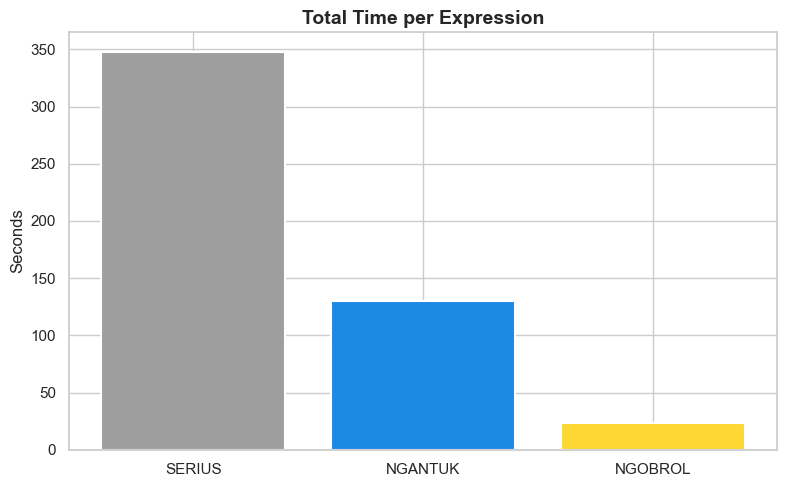

Saved to ./charts/total_time_per_expression.png


In [13]:
OUT_DIR = "charts"
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [color_for(e) for e in summary_df["Expression"]]
ax.bar(summary_df["Expression"], summary_df["Seconds"], color=colors, edgecolor="white", linewidth=1.5)
ax.set_title("Total Time per Expression", fontsize=14, fontweight="bold")
ax.set_ylabel("Seconds")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "total_time_per_expression.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to ./{OUT_DIR}/total_time_per_expression.png")
